In [2]:
import pandas as pd

# Load the dataset
file_path = r"C:\Users\user\Downloads\8. Sarcastic or Not Sarcastic Dataset-20250504T025540Z-1-001\8. Sarcastic or Not Sarcastic Dataset\sarcastic_headlines.csv"

df = pd.read_csv(file_path)

# Display basic info and first few rows
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB


(None,
                                             headline  is_sarcastic
 0  thirtysomething scientists unveil doomsday clo...             1
 1  dem rep. totally nails why congress is falling...             0
 2  eat your veggies: 9 deliciously different recipes             0
 3  inclement weather prevents liar from getting t...             1
 4  mother comes pretty close to using word 'strea...             1)

In [4]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Instantiate lemmatizer and stopword set
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define contraction mapping
contractions = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not", "can't": "cannot", 
    "couldn't": "could not", "won't": "will not", "wouldn't": "would not", "shouldn't": "should not",
    "i'm": "i am", "it's": "it is", "he's": "he is", "she's": "she is", "that's": "that is",
    "what's": "what is", "there's": "there is", "isn't": "is not", "aren't": "are not"
}

# Cleaning function
def clean_text(text):
    text = text.lower()  # Lowercase
    for word, replacement in contractions.items():
        text = text.replace(word, replacement)  # Expand contractions
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'\@[\w]*', '', text)  # Remove @mentions
    text = re.sub(r'\#[\w]*', '', text)  # Remove hashtags
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]  # Remove stopwords & lemmatize
    return " ".join(words)

# Apply cleaning
df['cleaned_headline'] = df['headline'].apply(clean_text)

# Display few cleaned examples
df[['headline', 'cleaned_headline']].head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,headline,cleaned_headline
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...


In [49]:
!pip install wordcloud

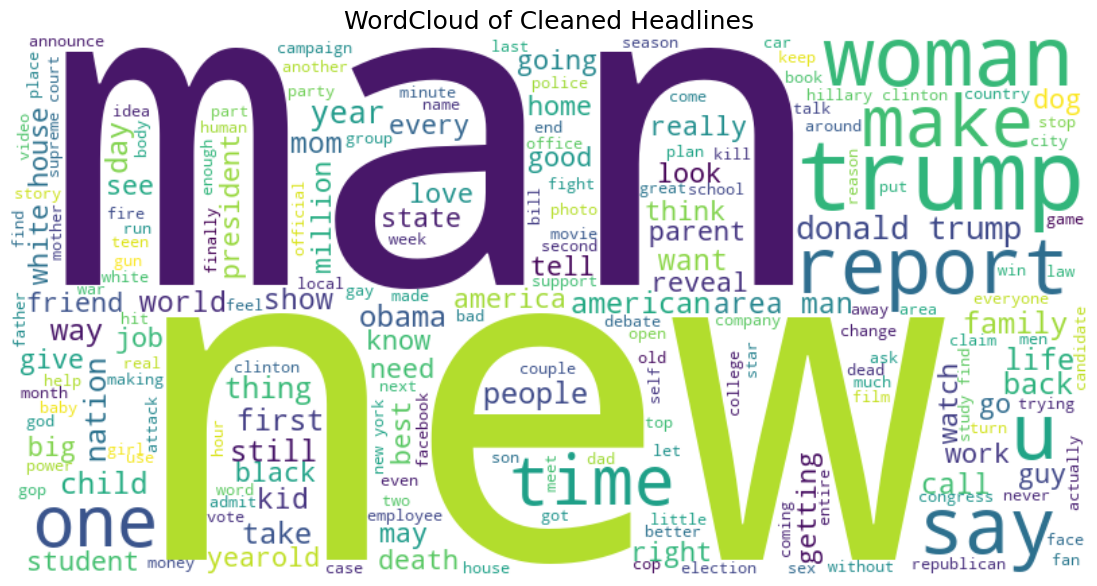

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string
all_text = " ".join(df['cleaned_headline'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Cleaned Headlines", fontsize=18)
plt.show()


In [33]:
!pip install tensorflow


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import numpy as np


# Step 4: Tokenization
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_headline'])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_headline'])

# Step 5: Padding using 95th percentile length
seq_lengths = [len(seq) for seq in sequences]
max_len = int(np.percentile(seq_lengths, 95))  # 95th percentile
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Step 6: Train-test split (80/20)
X = padded_sequences
y = df['is_sarcastic'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Vocabulary size:", len(tokenizer.word_index) + 1)
print("Max sequence length:", max_len)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))



Vocabulary size: 25053
Max sequence length: 11
Training samples: 22895
Testing samples: 5724


In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import BinaryCrossentropy

# Define parameters
vocab_size = len(tokenizer.word_index) + 1  # +1 for OOV token
embedding_dim = 64

# Build Regularized Simple RNN Model
model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))
model_rnn.add(SimpleRNN(
    units=32,                          # Reduced to prevent overfitting
    dropout=0.5,                       # Dropout on inputs
    recurrent_dropout=0.5,            # Dropout on recurrent connections
    kernel_regularizer=l2(0.001)      # L2 regularization
))
model_rnn.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))

# Compile the model
model_rnn.compile(loss=BinaryCrossentropy(label_smoothing=0.05), optimizer='adam', metrics=['accuracy', 'AUC'])

# Show model summary
model_rnn.summary()


early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - AUC: 0.5184 - accuracy: 0.5143 - loss: 0.7611 - val_AUC: 0.6049 - val_accuracy: 0.5656 - val_loss: 0.7219
Epoch 2/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - AUC: 0.5353 - accuracy: 0.5384 - loss: 0.7262 - val_AUC: 0.6248 - val_accuracy: 0.5824 - val_loss: 0.7072
Epoch 3/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - AUC: 0.5933 - accuracy: 0.5787 - loss: 0.7044 - val_AUC: 0.7802 - val_accuracy: 0.7102 - val_loss: 0.6110
Epoch 4/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - AUC: 0.7387 - accuracy: 0.6951 - loss: 0.6339 - val_AUC: 0.7987 - val_accuracy: 0.7342 - val_loss: 0.5969
Epoch 5/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - AUC: 0.7984 - accuracy: 0.7729 - loss: 0.5703 - val_AUC: 0.8074 - val_accuracy: 0.7486 - val_loss: 0.6072
Epoch 6/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - AUC: 0.8348 - accuracy: 0.8084 - loss: 0.5225 - val_AUC: 0.8432 - val_accuracy: 0.7609 - val_loss: 0.5728
Epoch 7/10
287/287 ━━━━━━━━━━━━━━━

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ (None, 11, 64)              │       1,603,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,819,589 (18.39 MB)

 Trainable params: 1,606,529 (6.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,213,060 (12.26 MB)

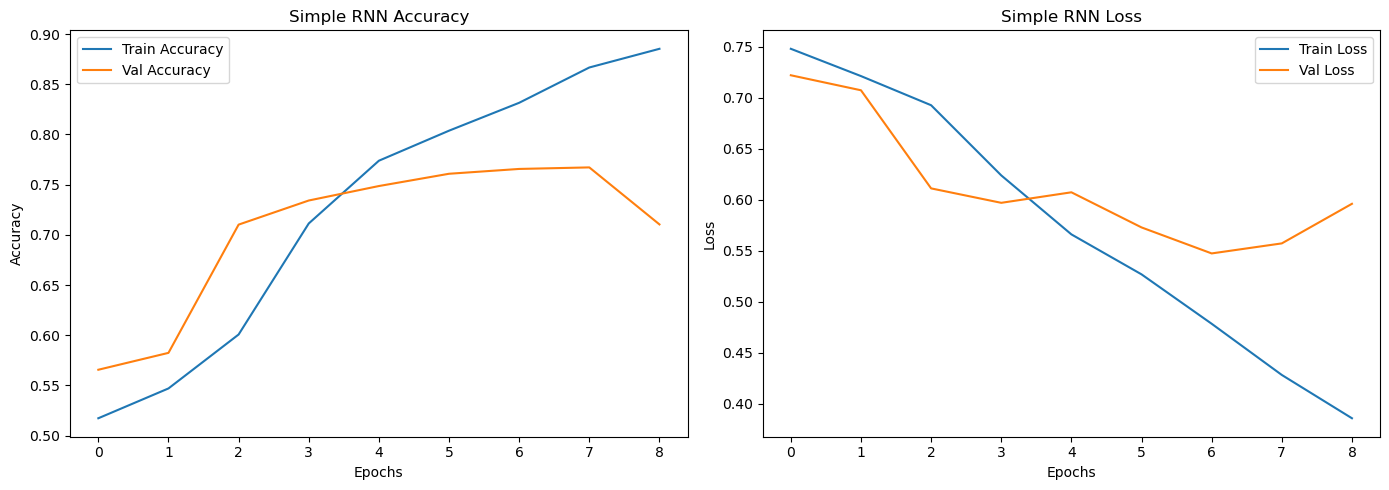

In [50]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Set up EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train the Simple RNN model
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

model_rnn.summary()


# Plot training vs validation accuracy and loss
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Val Accuracy')
plt.title("Simple RNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title("Simple RNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Embedding, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

# Build improved LSTM model
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model_lstm.add(LSTM(
    units=64,
    dropout=0.5,                # Prevent overfitting on inputs
    recurrent_dropout=0.5,      # Prevent overfitting on memory/state
    kernel_regularizer=l2(0.001)
))
model_lstm.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))

# Compile with AUC
model_lstm.compile(
    loss=BinaryCrossentropy(label_smoothing=0.05),
    optimizer=Adam(learning_rate=1e-4),  # Was likely 1e-3
    metrics=['accuracy', 'AUC']
)
# Model summary
model_lstm.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - AUC: 0.5442 - accuracy: 0.5188 - loss: 0.7820 - val_AUC: 0.6056 - val_accuracy: 0.5589 - val_loss: 0.7450
Epoch 2/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - AUC: 0.6332 - accuracy: 0.5909 - loss: 0.7267 - val_AUC: 0.7861 - val_accuracy: 0.7150 - val_loss: 0.6122
Epoch 3/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - AUC: 0.8301 - accuracy: 0.7558 - loss: 0.5686 - val_AUC: 0.8364 - val_accuracy: 0.7563 - val_loss: 0.5496
Epoch 4/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - AUC: 0.8859 - accuracy: 0.8188 - loss: 0.4907 - val_AUC: 0.8539 - val_accuracy: 0.7731 - val_loss: 0.5197
Epoch 5/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - AUC: 0.9117 - accuracy: 0.8436 - loss: 0.4428 - val_AUC: 0.8626 - val_accuracy: 0.7803 - val_loss: 0.5071
Epoch 6/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - AUC: 0.9265 - accuracy: 0.8649 - loss: 0.4114 - val_AUC: 0.8665 - val_accuracy: 0.7818 - val_loss: 0.5033
Epoch 7/10
287/287 ━━━━━━━━━━━━━━

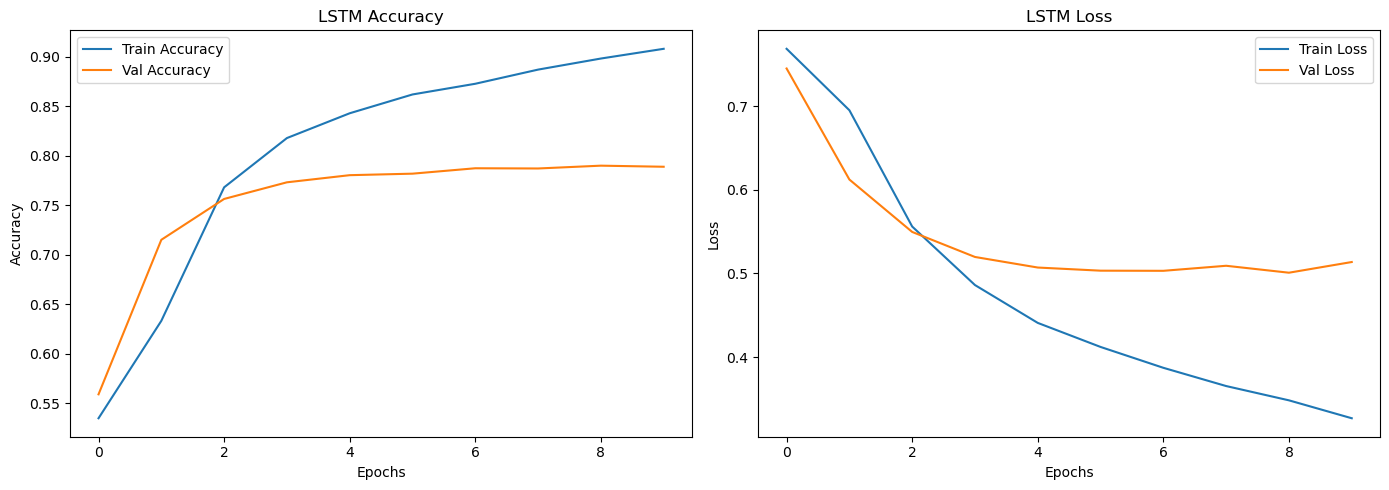

In [54]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Set up EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train the LSTM model
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Plot training vs validation accuracy and loss
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.title("LSTM Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title("LSTM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [30]:
import gensim.downloader as api
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Load pretrained Google Word2Vec model (300-dimensional)
word2vec_model = api.load("word2vec-google-news-300")
embedding_dim = 300  # Word2Vec uses 300 dimensions

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in word2vec_model:
        embedding_matrix[i] = word2vec_model[word]

# Build LSTM model with Word2Vec embeddings
model_word2vec = Sequential()
model_word2vec.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
))
model_word2vec.add(LSTM(64))
model_word2vec.add(Dense(1, activation='sigmoid'))

# Compile the model
model_word2vec.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Show summary
model_word2vec.summary()


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │       7,515,900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,515,900 (28.67 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,515,900 (28.67 MB)

Epoch 1/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6853 - loss: 0.5878 - val_accuracy: 0.7620 - val_loss: 0.4866
Epoch 2/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7813 - loss: 0.4599 - val_accuracy: 0.7855 - val_loss: 0.4501
Epoch 3/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8058 - loss: 0.4156 - val_accuracy: 0.7949 - val_loss: 0.4298
Epoch 4/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8213 - loss: 0.3861 - val_accuracy: 0.8006 - val_loss: 0.4297
Epoch 5/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8471 - loss: 0.3441 - val_accuracy: 0.8056 - val_loss: 0.4177
Epoch 6/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8639 - loss: 0.3106 - val_accuracy: 0.8059 - val_loss: 0.4245
Epoch 7/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8846 - loss: 0.2719 - val_accuracy: 0.8065 - val_loss: 0.4445


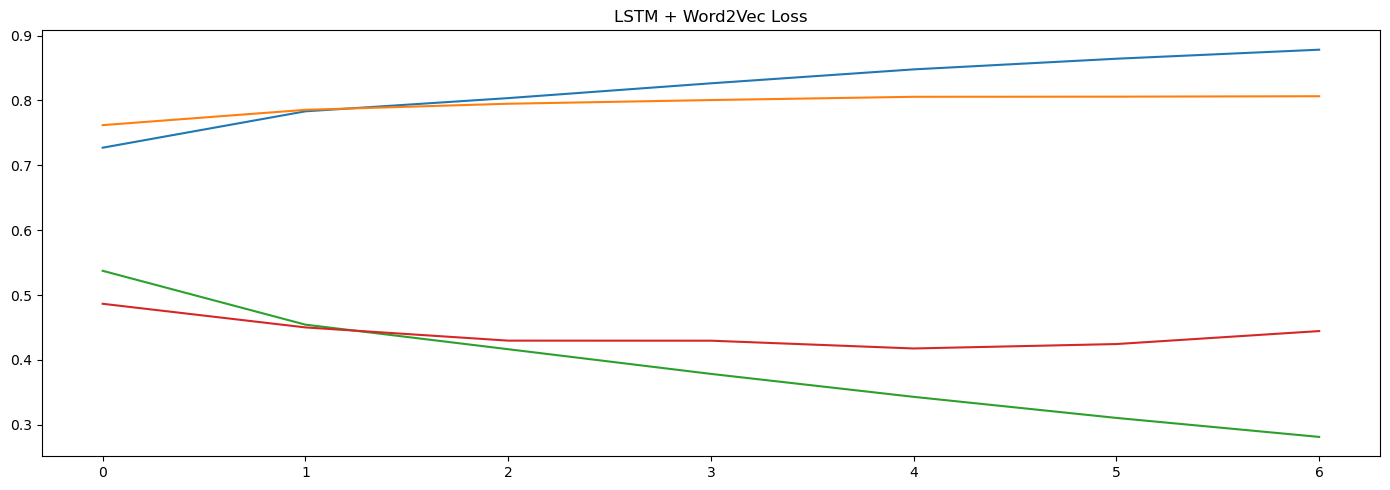

In [32]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_word2vec = model_word2vec.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


# Plot accuracy and loss
plt.figure(figsize=(14, 5))
# Accuracy
plt.plot(history_word2vec.history['accuracy'], label='Train Accuracy')
plt.plot(history_word2vec.history['val_accuracy'], label='Val Accuracy')
plt.title("LSTM + Word2Vec Accuracy")

# Loss
plt.plot(history_word2vec.history['loss'], label='Train Loss')
plt.plot(history_word2vec.history['val_loss'], label='Val Loss')
plt.title("LSTM + Word2Vec Loss")



plt.tight_layout()
plt.show()


179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


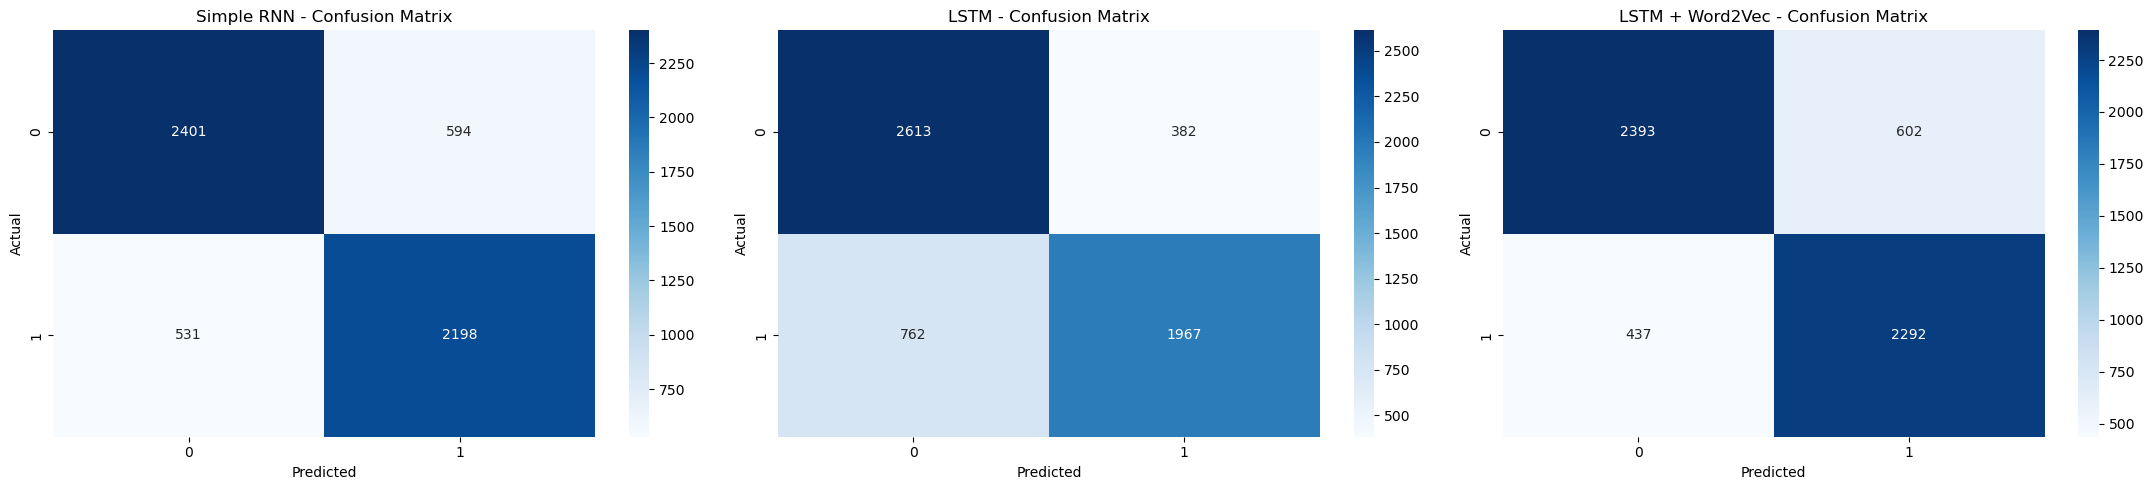

Simple RNN Accuracy: 80.35%
LSTM Accuracy: 80.01%
LSTM + Word2Vec Accuracy: 81.85%
Simple RNN:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81      2995
           1       0.79      0.81      0.80      2729

    accuracy                           0.80      5724
   macro avg       0.80      0.80      0.80      5724
weighted avg       0.80      0.80      0.80      5724

LSTM:
               precision    recall  f1-score   support

           0       0.77      0.87      0.82      2995
           1       0.84      0.72      0.77      2729

    accuracy                           0.80      5724
   macro avg       0.81      0.80      0.80      5724
weighted avg       0.80      0.80      0.80      5724

LSTM + Word2Vec:
               precision    recall  f1-score   support

           0       0.85      0.80      0.82      2995
           1       0.79      0.84      0.82      2729

    accuracy                           0.82      5724
   macr

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict using 3 models
y_pred_rnn = (model_rnn.predict(X_test) > 0.5).astype("int32")
y_pred_lstm = (model_lstm.predict(X_test) > 0.5).astype("int32")
y_pred_word2vec = (model_word2vec.predict(X_test) > 0.5).astype("int32")

# Store evaluations
evaluation_results = {
    "Simple RNN": {
        "accuracy": accuracy_score(y_test, y_pred_rnn),
        "confusion": confusion_matrix(y_test, y_pred_rnn),
        "report": classification_report(y_test, y_pred_rnn, output_dict=True)
    },
    "LSTM": {
        "accuracy": accuracy_score(y_test, y_pred_lstm),
        "confusion": confusion_matrix(y_test, y_pred_lstm),
        "report": classification_report(y_test, y_pred_lstm, output_dict=True)
    },
    "LSTM + Word2Vec": {
        "accuracy": accuracy_score(y_test, y_pred_word2vec),
        "confusion": confusion_matrix(y_test, y_pred_word2vec),
        "report": classification_report(y_test, y_pred_word2vec, output_dict=True)
    }
}

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for i, (model_name, result) in enumerate(evaluation_results.items()):
    sns.heatmap(result["confusion"], annot=True, fmt="d", cmap="Blues", ax=axes[i])
    axes[i].set_title(f"{model_name} - Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Print accuracy scores
for model, data in evaluation_results.items():
    print(f"{model} Accuracy: {round(data['accuracy'] * 100, 2)}%")



print("Simple RNN:\n", classification_report(y_test, y_pred_rnn))
print("LSTM:\n", classification_report(y_test, y_pred_lstm))
print("LSTM + Word2Vec:\n", classification_report(y_test, y_pred_word2vec))



In [36]:
!pip install gradio


In [38]:
import gradio as gr

# Define label mapping
label_map = {0: "Not Sarcastic 😐", 1: "Sarcastic 😂"}

# Prediction function using the Simple RNN model
def predict_sarcasm(text):
    text = text.lower()
    for word, replacement in contractions.items():
        text = text.replace(word, replacement)
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@[\w]*', '', text)
    text = re.sub(r'\#[\w]*', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    cleaned_text = " ".join(words)

    seq = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    pred = model_word2vec.predict(padded)[0][0]
    label = 1 if pred > 0.5 else 0
    confidence = round(pred if label else 1 - pred, 3)
    return f"{label_map[label]} (Confidence: {confidence})"

# Launch Gradio Interface
gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.components.Textbox(lines=2, placeholder="Enter a news headline..."),
    outputs=gr.components.Textbox(),
    title="Sarcasm Detector 📰😂 (LSTM + Word2Vec)",
    description="Type a news headline below to detect sarcasm using a trained RNN model."
).launch(share=True)


* Running on local URL:  http://127.0.0.1:7861

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
